# Setting

In [67]:
# 현재 업로드된 파일 확인
list.files("/content")

[1] "best_arima_model.rds"   "part94_sarima_data.csv" "sample_data"

In [ ]:
# 패키지 설치
install.packages(c("astsa", "forecast"))

# 패키지 로드
library(astsa)
library(forecast)

# Data Load

In [42]:
data = read.csv('part94_sarima_data.csv', check.names = FALSE)
head(data)

,Part Number,CRET_TIME,D일 투입예정 수량(D일계획)
,<chr>,<chr>,<int>
1,Part 94,2021-09-13 18:30:00,42
2,Part 94,2021-09-14 17:30:00,40
3,Part 94,2021-09-15 16:33:00,40
4,Part 94,2021-09-16 17:06:00,47
5,Part 94,2021-09-17 06:32:00,46
6,Part 94,2021-09-18 07:13:00,46


In [43]:
X_t <- ts(data$`D일 투입예정 수량(D일계획)`, frequency=1)
X_t

A Time Series:
 [1] 42 40 40 47 46 46 46 46 46 46 46 46 46 46 40 35 39 45 40 41 41 40 41 39 38
[26] 42 42 42 42 42 28 35 35 35 35 37 44 45 43 35 35 35 38 45 45 47 45 45 28

In [44]:
data$Date <- as.Date(substr(data$CRET_TIME, 1, 10))
data$MonthDay <- format(data$Date, "%m/%d")
data$MonthDay

[1] "09/13" "09/14" "09/15" "09/16" "09/17" "09/18" "09/19" "09/20" "09/21"
[10] "09/22" "09/23" "09/24" "09/25" "09/26" "09/27" "09/28" "09/29" "09/30"
[19] "10/01" "10/02" "10/03" "10/04" "10/05" "10/06" "10/07" "10/08" "10/09"
[28] "10/10" "10/11" "10/12" "10/13" "10/14" "10/15" "10/16" "10/17" "10/18"
[37] "10/19" "10/20" "10/21" "10/22" "10/23" "10/24" "10/25" "10/26" "10/27"
[46] "10/28" "10/29" "10/30" "11/01"

In [48]:
dim(data)

[1] 49  5

# EDA

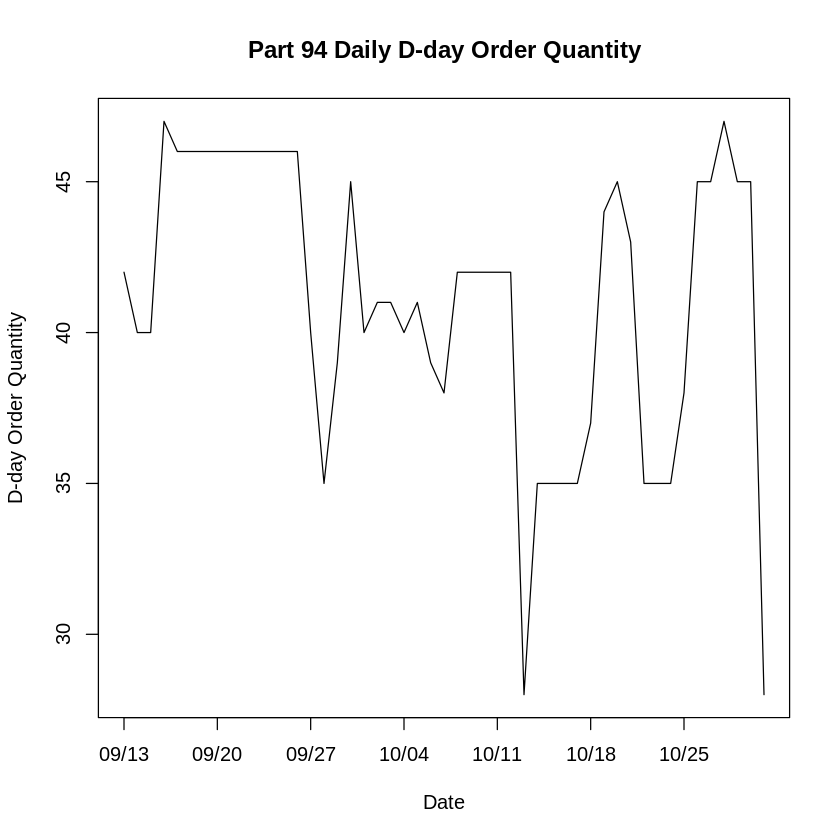

In [20]:
# 7일 간격으로 날짜 표시
idx <- seq(1, length(X_t), by = 7)

ts.plot(
  X_t,
  gpars = list(
    xaxt = "n",
    xlab = "Date",
    ylab = "D-day Order Quantity",
    main = "Part 94 Daily D-day Order Quantity"
  )
)

axis(
  side = 1,
  at = time(X_t)[idx],
  labels = data$MonthDay[idx]
)

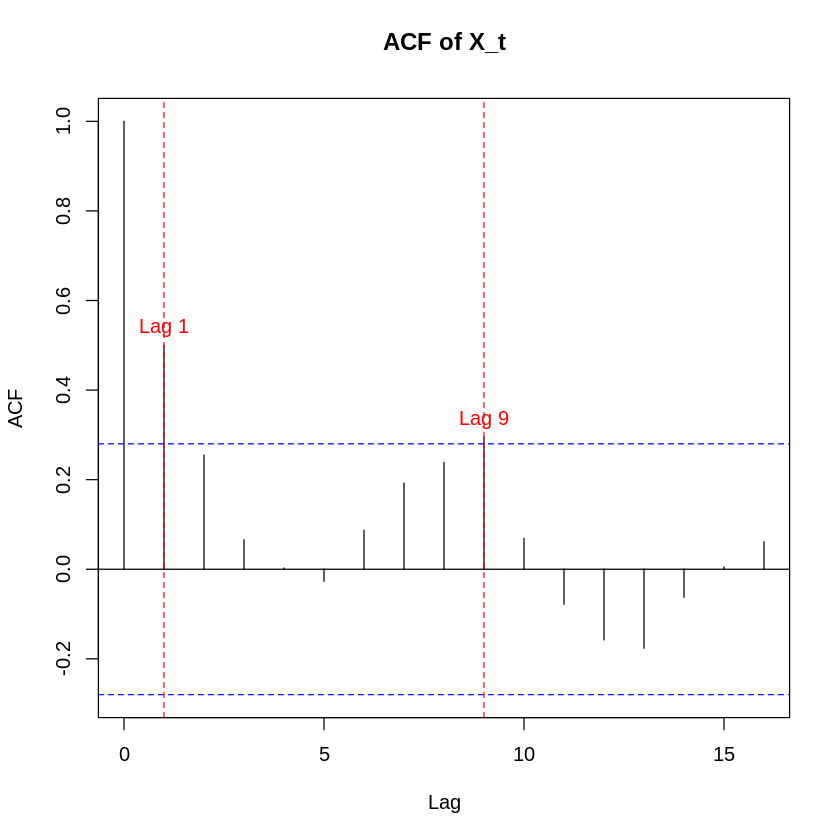

In [58]:
# @title
# ACF 계산
acf_plot <- acf(
  X_t,
  lag.max = 16,
  plot = FALSE
)

# ACF 그래프
plot(
  acf_plot,
  main = "ACF of X_t",
  xlab = "Lag"
)

# 95% confidence interval
ci <- 1.96 / sqrt(length(X_t))

# lag 0 제외
acf_values <- as.numeric(acf_plot$acf[-1])
lags <- as.numeric(acf_plot$lag[-1])

# confidence interval을 벗어난 lag 찾기
sig_lags <- lags[
  abs(acf_values) > ci
]

sig_values <- acf_values[
  abs(acf_values) > ci
]

# 유의한 lag마다 빨간 세로선 + Lag 값 표시
for (i in seq_along(sig_lags)) {

  abline(
    v = sig_lags[i],
    col = "red",
    lty = 2
  )

  text(
    x = sig_lags[i],
    y = sig_values[i],
    labels = paste0("Lag ", sig_lags[i]),
    col = "red",
    pos = ifelse(sig_values[i] > 0, 3, 1)
  )
}

[1] 1

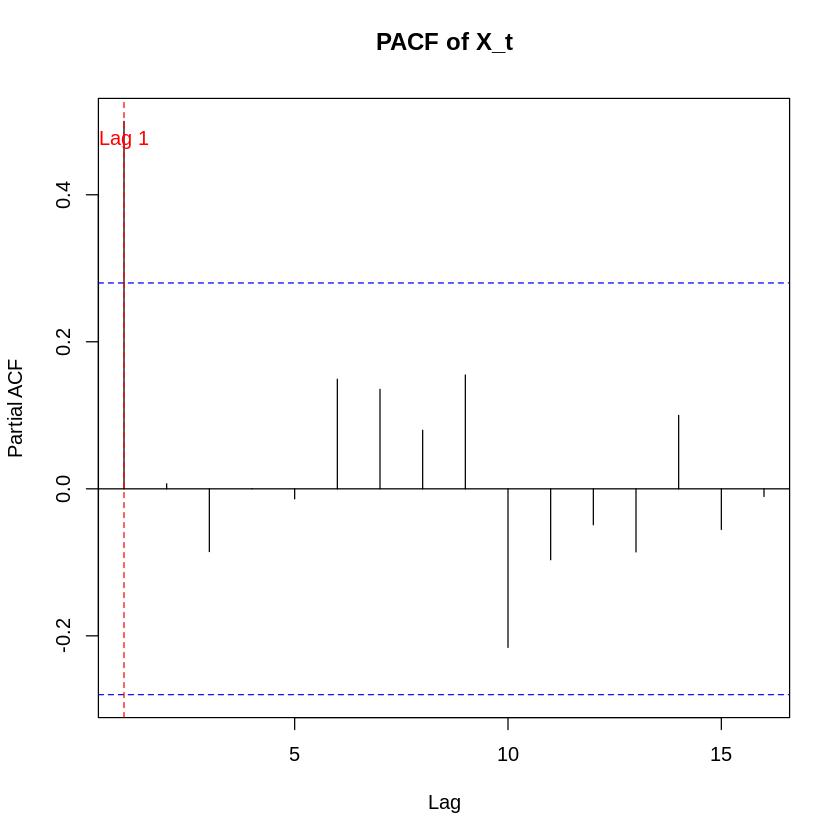

In [60]:
# @title
# PACF 계산
pacf_plot <- pacf(
  X_t,
  lag.max = 16,
  plot = FALSE
)

# PACF 그래프
plot(
  pacf_plot,
  main = "PACF of X_t",
  xlab = "Lag"
)

# 95% confidence interval
ci <- 1.96 / sqrt(length(X_t))

# PACF 값과 lag
pacf_values <- as.numeric(pacf_plot$acf)
lags <- as.numeric(pacf_plot$lag)

# confidence interval을 벗어난 lag 찾기
idx <- abs(pacf_values) > ci

sig_lags <- lags[idx]
sig_values <- pacf_values[idx]

# 빨간 세로선
abline(
  v = sig_lags,
  col = "red",
  lty = 2
)

# Lag 값 표시
text(
  x = sig_lags,
  y = sig_values,
  labels = paste0("Lag ", sig_lags),
  col = "red",
  pos = ifelse(sig_values > 0, 1, 3)
)

# 유의한 lag 출력
sig_lags

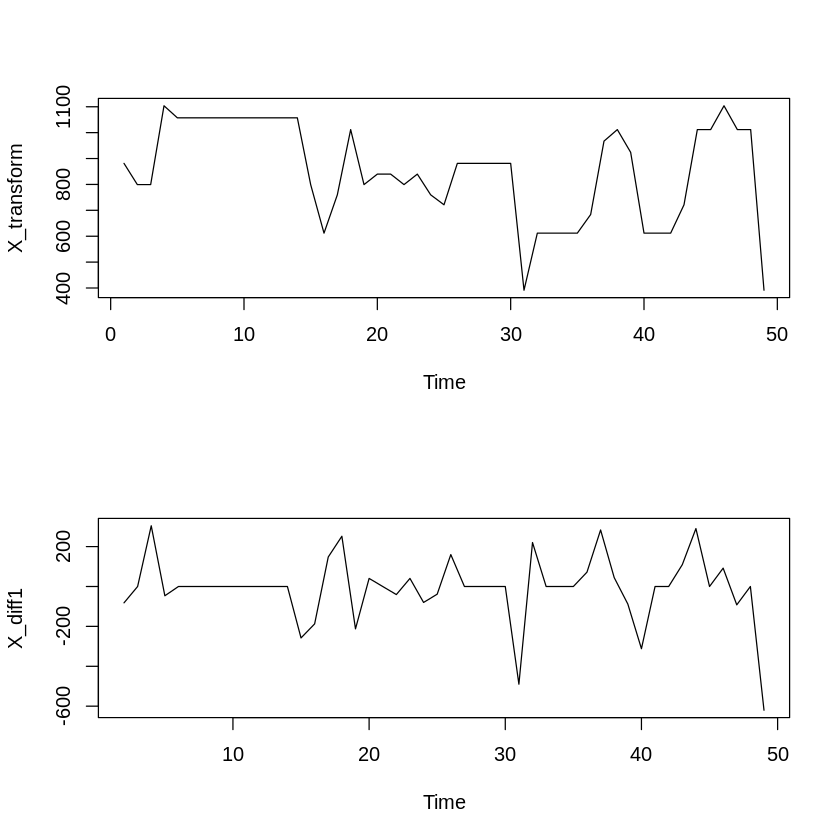

In [63]:
lambda <- BoxCox.lambda(X_t)
X_transform <- BoxCox(X_t, lambda)
# ndiffs(X_t)

X_diff1 <- diff(X_transform, lag=1)
par(mfrow = c(2,1))
ts.plot(X_transform)
ts.plot(X_diff1)

* 원본 시계열에서 뚜렷한 추세가 관찰되지 않아 d=0을 우선 고려했으며 ACF/PACF 분석에서 Lag 1의 자기상관이 두드러져 AR(1), MA(1), ARMA(1,1) 등 낮은 차수 모델을 주요 후보로 설정하였다.

# Modeling

DATA SPLIT
Total: 49 
Train: 34 
Val  : 5 
Test : 10 

Train: 2021-09-13 ~ 2021-10-16 
Val  : 2021-10-17 ~ 2021-10-21 
Test : 2021-10-22 ~ 2021-11-01 

AUTO ARIMA - TRAIN ONLY
Series: X_train 
ARIMA(0,1,1) 

Coefficients:
          ma1
      -0.4556
s.e.   0.2056

sigma^2 = 12.74:  log likelihood = -88.42
AIC=180.84   AICc=181.24   BIC=183.83

Validation target count: 3 
Validation target dates: 2021-10-19 ~ 2021-10-21 

VALIDATION MODEL COMPARISON
          Model p d q      AIC     AICc      BIC Ljung_Box_p Validation_N
6  ARIMA(0,0,1) 0 0 1 189.9110 190.7110 194.4901   0.1970742            3
12 ARIMA(0,0,2) 0 0 2 190.0816 191.4610 196.1871   0.3138902            3
1  ARIMA(1,0,0) 1 0 0 185.6673 186.4673 190.2464   0.9038299            3
2  ARIMA(2,0,0) 2 0 0 187.5447 188.9241 193.6502   0.8464652            3
7  ARIMA(1,0,1) 1 0 1 187.4577 188.8370 193.5632   0.8732646            3
8  ARIMA(2,0,1) 2 0 1 189.1903 191.3331 196.8221   0.7920676            3
14 ARIMA(2,0,2) 2 0 2 190.940

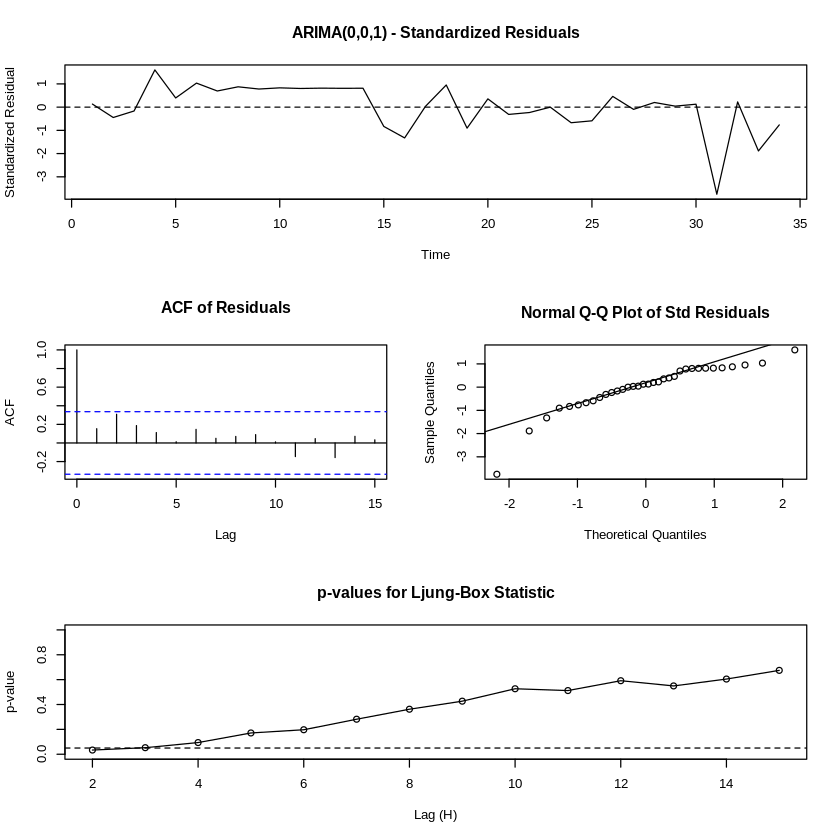

In [54]:
# ============================================================
# ARIMA 3-Step Ahead Forecasting Pipeline
#
# Train : Validation : Test = 70 : 10 : 20
#
# 1. Train에서 여러 ARIMA 후보 학습
# 2. Validation 3-step ahead MAE로 모델 선택
# 3. Train + Validation 재학습하지 않음
# 4. Test target의 3-step 전까지만 사용
# 5. 정확히 3-step ahead Test MAE 계산
# ============================================================

library(forecast)


# ============================================================
# 1. Target / Date
# ============================================================

y <- data[["D일 투입예정 수량(D일계획)"]]

data$Date <- as.Date(
  substr(data$CRET_TIME, 1, 10)
)

n <- length(y)


# ============================================================
# 2. Train / Validation / Test Split
# 70% / 10% / 20%
# ============================================================

train_end <- round(n * 0.7)
val_end   <- round(n * 0.8)
test_start <- val_end + 1


y_train <- y[1:train_end]

y_val <- y[
  (train_end + 1):val_end
]

y_test <- y[
  test_start:n
]


date_train <- data$Date[
  1:train_end
]

date_val <- data$Date[
  (train_end + 1):val_end
]

date_test <- data$Date[
  test_start:n
]


cat("==============================\n")
cat("DATA SPLIT\n")
cat("==============================\n")

cat("Total:", n, "\n")
cat("Train:", length(y_train), "\n")
cat("Val  :", length(y_val), "\n")
cat("Test :", length(y_test), "\n")

cat(
  "\nTrain:",
  as.character(min(date_train)),
  "~",
  as.character(max(date_train)),
  "\n"
)

cat(
  "Val  :",
  as.character(min(date_val)),
  "~",
  as.character(max(date_val)),
  "\n"
)

cat(
  "Test :",
  as.character(min(date_test)),
  "~",
  as.character(max(date_test)),
  "\n"
)


# ============================================================
# 3. Train Time Series
# ============================================================

X_train <- ts(
  y_train,
  frequency = 1
)


# ============================================================
# 4. Auto ARIMA 결과 참고
# 최종 선택은 Validation MAE로 함
# ============================================================

auto_model <- auto.arima(
  X_train,
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE
)


cat("\n==============================\n")
cat("AUTO ARIMA - TRAIN ONLY\n")
cat("==============================\n")

print(auto_model)


# ============================================================
# 5. ARIMA Candidate Grid
#
# 작은 데이터이므로 낮은 차수 위주
# ============================================================

candidate_grid <- expand.grid(
  p = 0:2,
  d = 0:1,
  q = 0:2
)


# ARIMA(0,0,0) 제외
candidate_grid <- candidate_grid[
  !(
    candidate_grid$p == 0 &
    candidate_grid$d == 0 &
    candidate_grid$q == 0
  ),
]


# ============================================================
# 6. Fixed-model 3-step Forecast 함수
#
# 중요:
# model_template의 coefficient는 Train에서 학습한 값 그대로 사용
#
# target의 3-step 전까지만 history에 넣고
# 정확히 세 번째 forecast를 가져옴
# ============================================================

forecast_3step_fixed <- function(
  y,
  target_indices,
  model_template
) {

  predictions <- numeric(0)
  actuals <- numeric(0)
  used_indices <- integer(0)


  for (target_idx in target_indices) {

    # ------------------------------------------
    # Target의 정확히 3-step 전까지
    # ------------------------------------------

    history_end <- target_idx - 3

    if (history_end < 1) {
      next
    }


    history <- y[
      1:history_end
    ]

    history_ts <- ts(
      history,
      frequency = 1
    )


    # ------------------------------------------
    # 같은 ARIMA model parameter 사용
    # parameter 재추정하지 않음
    # ------------------------------------------

    model_current <- Arima(
      history_ts,
      model = model_template
    )


    # ------------------------------------------
    # 3-step ahead
    # ------------------------------------------

    fc <- forecast(
      model_current,
      h = 3
    )


    pred <- as.numeric(
      fc$mean[3]
    )


    predictions <- c(
      predictions,
      pred
    )

    actuals <- c(
      actuals,
      y[target_idx]
    )

    used_indices <- c(
      used_indices,
      target_idx
    )
  }


  return(
    list(
      prediction = predictions,
      actual = actuals,
      target_index = used_indices
    )
  )
}


# ============================================================
# 7. Validation Target
#
# Train 전체로 학습한 model을 검증하려면
# 최소 Train 종료 + 3 step 이후 target부터 평가
#
# 예:
# Train 끝 = index 34
# 첫 valid 3-step target = index 37
# ============================================================

val_target_start <- train_end + 3


if (val_target_start > val_end) {
  stop(
    "Validation 구간이 너무 짧아서 3-step ahead 평가가 불가능합니다."
  )
}


val_indices <- val_target_start:val_end


cat("\nValidation target count:",
    length(val_indices), "\n")

cat(
  "Validation target dates:",
  as.character(data$Date[min(val_indices)]),
  "~",
  as.character(data$Date[max(val_indices)]),
  "\n"
)


# ============================================================
# 8. Train에서 후보 모델 학습
#    Validation 3-step MAE 비교
# ============================================================

candidate_results <- data.frame()

candidate_models <- list()


for (i in 1:nrow(candidate_grid)) {

  p_i <- candidate_grid$p[i]
  d_i <- candidate_grid$d[i]
  q_i <- candidate_grid$q[i]


  # ----------------------------------------------------------
  # Train ONLY fitting
  # ----------------------------------------------------------

  model_i <- tryCatch(

    Arima(
      X_train,
      order = c(
        p_i,
        d_i,
        q_i
      )
    ),

    error = function(e) {
      NULL
    }
  )


  if (is.null(model_i)) {
    next
  }


  # ----------------------------------------------------------
  # Validation 정확히 3-step ahead
  # ----------------------------------------------------------

  val_result <- forecast_3step_fixed(
    y = y,
    target_indices = val_indices,
    model_template = model_i
  )


  val_mae <- mean(
    abs(
      val_result$actual -
      val_result$prediction
    )
  )


  # ----------------------------------------------------------
  # Ljung-Box
  # ----------------------------------------------------------

  fitdf_i <- p_i + q_i

  lag_lb <- max(
    fitdf_i + 1,
    min(
      7,
      floor(
        length(residuals(model_i)) / 5
      )
    )
  )


  lb <- Box.test(
    residuals(model_i),
    lag = lag_lb,
    type = "Ljung-Box",
    fitdf = fitdf_i
  )


  # ----------------------------------------------------------
  # Model name
  # ----------------------------------------------------------

  model_name <- paste0(
    "ARIMA(",
    p_i, ",",
    d_i, ",",
    q_i, ")"
  )


  # ----------------------------------------------------------
  # Save result
  # ----------------------------------------------------------

  candidate_results <- rbind(

    candidate_results,

    data.frame(

      Model = model_name,

      p = p_i,
      d = d_i,
      q = q_i,

      AIC = AIC(model_i),
      AICc = model_i$aicc,
      BIC = BIC(model_i),

      Ljung_Box_p = lb$p.value,

      Validation_N = length(
        val_result$actual
      ),

      Validation_MAE_3Step = val_mae

    )
  )


  candidate_models[[model_name]] <- model_i
}


# ============================================================
# 9. Validation MAE 기준 정렬
#
# 1순위: 3-step Validation MAE
# 2순위: AICc
# ============================================================

candidate_results <- candidate_results[
  order(
    candidate_results$Validation_MAE_3Step,
    candidate_results$AICc
  ),
]


cat("\n==============================\n")
cat("VALIDATION MODEL COMPARISON\n")
cat("==============================\n")

print(candidate_results)


# ============================================================
# 10. Final Model 선택
#
# Validation MAE 가장 작은 모델
# ★ 재학습하지 않음
# ============================================================

best_model_name <- candidate_results$Model[1]

final_model <- candidate_models[[best_model_name]]


cat("\n==============================\n")
cat("SELECTED FINAL MODEL\n")
cat("==============================\n")

cat(
  "Selected:",
  best_model_name,
  "\n"
)

cat(
  "Validation 3-Step MAE:",
  candidate_results$Validation_MAE_3Step[1],
  "\n"
)

print(final_model)


# ============================================================
# 11. Final Model Order
# ============================================================

selected_order <- arimaorder(
  final_model
)

p <- as.numeric(
  selected_order["p"]
)

d <- as.numeric(
  selected_order["d"]
)

q <- as.numeric(
  selected_order["q"]
)


# ============================================================
# 12. Final Model Residual Diagnostics
#
# Train-only selected model
# ============================================================

res <- residuals(
  final_model
)

std_res <- as.numeric(
  scale(res)
)

fitdf <- p + q


# ------------------------------------------------------------
# Final Ljung-Box
# ------------------------------------------------------------

lag_final <- max(
  fitdf + 1,
  min(
    7,
    floor(length(res) / 5)
  )
)


ljung_final <- Box.test(
  res,
  lag = lag_final,
  type = "Ljung-Box",
  fitdf = fitdf
)


cat("\n==============================\n")
cat("FINAL MODEL LJUNG-BOX\n")
cat("==============================\n")

print(ljung_final)


# ============================================================
# 13. Lag별 Ljung-Box p-value
# ============================================================

max_lag <- min(
  15,
  floor(length(res) / 2)
)

start_lag <- fitdf + 1

lags <- start_lag:max_lag


lb_pvalues <- sapply(
  lags,

  function(L) {

    Box.test(
      res,
      lag = L,
      type = "Ljung-Box",
      fitdf = fitdf
    )$p.value

  }
)


# ============================================================
# 14. Residual Diagnostic Plot
# ============================================================

layout(
  matrix(
    c(
      1, 1,
      2, 3,
      4, 4
    ),
    nrow = 3,
    byrow = TRUE
  )
)


# Standardized Residuals
plot(
  std_res,
  type = "l",

  xlab = "Time",
  ylab = "Standardized Residual",

  main = paste0(
    best_model_name,
    " - Standardized Residuals"
  )
)

abline(
  h = 0,
  lty = 2
)


# ACF of Residuals
acf(
  res,
  main = "ACF of Residuals"
)


# Normal Q-Q
qqnorm(
  std_res,
  main = "Normal Q-Q Plot of Std Residuals"
)

qqline(
  std_res
)


# Ljung-Box p-values
plot(
  lags,
  lb_pvalues,

  type = "o",
  pch = 1,

  ylim = c(0, 1),

  xlab = "Lag (H)",
  ylab = "p-value",

  main = "p-values for Ljung-Box Statistic"
)

abline(
  h = 0.05,
  lty = 2
)


layout(1)


# ============================================================
# 15. Test Targets
#
# Test 10개 전부 평가
# ============================================================

test_indices <- test_start:n


# ============================================================
# 16. Test 정확히 3-step Ahead
#
# 예:
#
# target 10/22
# → 3-step 전까지 history
# → 3-step forecast
# → 10/22 실제값과 비교
#
# target 10/23
# → 3-step 전까지 history
# → 3-step forecast
# → 10/23 실제값과 비교
# ============================================================

test_result_3step <- forecast_3step_fixed(
  y = y,
  target_indices = test_indices,
  model_template = final_model
)


# ============================================================
# 17. Test 3-Step MAE
# ============================================================

test_mae_3step <- mean(
  abs(
    test_result_3step$actual -
    test_result_3step$prediction
  )
)


cat("\n==============================\n")
cat("FINAL TEST - 3 STEP AHEAD\n")
cat("==============================\n")

cat(
  "3-Step Ahead Test MAE:",
  test_mae_3step,
  "\n"
)


# ============================================================
# 18. Test Actual vs Prediction
# ============================================================

test_result <- data.frame(

  Date = data$Date[
    test_result_3step$target_index
  ],

  Actual =
    test_result_3step$actual,

  Predicted =
    test_result_3step$prediction,

  Absolute_Error =
    abs(
      test_result_3step$actual -
      test_result_3step$prediction
    )

)


print(test_result)


# ============================================================
# 19. Final Summary
# ============================================================

final_summary <- data.frame(

  Model = best_model_name,

  Validation_N =
    candidate_results$Validation_N[1],

  Validation_MAE_3Step =
    candidate_results$Validation_MAE_3Step[1],

  AIC =
    AIC(final_model),

  AICc =
    final_model$aicc,

  BIC =
    BIC(final_model),

  Ljung_Box_p =
    ljung_final$p.value,

  Test_N =
    length(test_result_3step$actual),

  Test_MAE_3Step =
    test_mae_3step

)


cat("\n==============================\n")
cat("FINAL SUMMARY\n")
cat("==============================\n")

print(final_summary)

In [66]:
best_idx <- which.min(candidate_results$Validation_MAE_3Step)
best_model <- candidate_models[[candidate_results$Model[best_idx]]]
# best_model <- readRDS("best_arima_model.rds")

| 모델            | 3-step ahead Test MAE | 특징                          |
| ------------- | --------------------: | --------------------------- |
| Tuned XGBoost |            **약 4.89** | 최근 3일 × 4개 변수               |
| ARIMA(0,0,1)         |            **약 5.60** | D-day 발주량 시계열만 사용           |
| LSTM          |            **약 5.62** | 최근 3일 × 4개 변수를 sequence로 사용 |
